In [146]:
using Pkg
pkg"activate ."
pkg"instantiate"

  Activating project at `C:\Users\felip\Arquivos Julia 2025.2\Notebooks Julia ONL`
Precompiling project...
   1251.0 ms  ? DomainSets
   2195.3 ms  ? Symbolics
   5844.9 ms  ? ModelingToolkit
   7275.1 ms  ? Optimization → OptimizationMTKExt


In [147]:
import Pkg; Pkg.add("ForwardDiff")

   Resolving package versions...
  No Changes to `C:\Users\felip\Arquivos Julia 2025.2\Notebooks Julia ONL\Project.toml`
  No Changes to `C:\Users\felip\Arquivos Julia 2025.2\Notebooks Julia ONL\Manifest.toml`
Precompiling project...
   1421.8 ms  ? DomainSets
   2471.2 ms  ? Symbolics
   6044.0 ms  ? ModelingToolkit
   7209.7 ms  ? Optimization → OptimizationMTKExt


In [148]:
import Pkg; Pkg.add("Interact")

   Resolving package versions...
  No Changes to `C:\Users\felip\Arquivos Julia 2025.2\Notebooks Julia ONL\Project.toml`
  No Changes to `C:\Users\felip\Arquivos Julia 2025.2\Notebooks Julia ONL\Manifest.toml`
Precompiling project...
   1523.5 ms  ? DomainSets
   2318.2 ms  ? Symbolics
   5896.5 ms  ? ModelingToolkit
   7340.9 ms  ? Optimization → OptimizationMTKExt


In [149]:
using ForwardDiff, Plots, Interact, LinearAlgebra
gr(size=(600, 400))

Plots.GRBackend()

In [150]:
function intervalo_inicial(f,x; s=1e-2, k=2.0)
    a, fa = x, f(x)
    b, fb = a + s, f(a + s)
    if fa < fb
        a, b = b, a
        fa, fb = fb, fa
    s = -s
    end
    while true
        c, fc = b + s, f(b + s)
        if fb < fc
            return a < c ? (a, c) : (c, a)
        end
        a, fa, b, fb = b, fb, c, fc
        s *= k
    end
end

intervalo_inicial (generic function with 1 method)

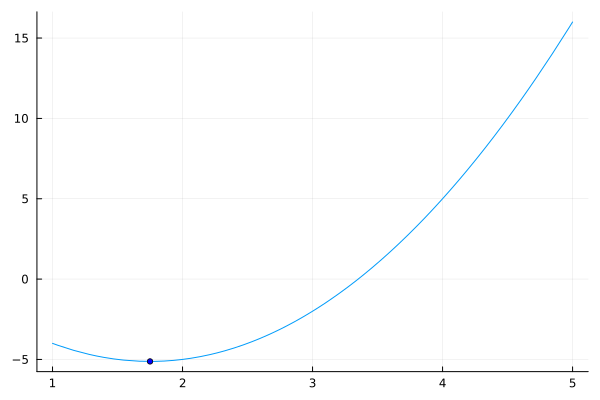

In [151]:
f(x)= 2*x^2 - 7*x+1
#f(0)
#a, b = -3, 7
plot(f, a, b, leg=false)
scatter!([7/4], [f(7/4)], c=:blue, ms=3)

In [152]:
intervalo_inicial(f, 0)

(0.64, 2.56)

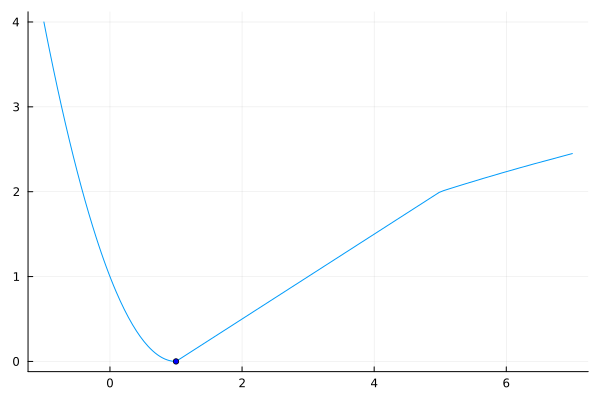

In [153]:
f(x) = if x ≤ 1
    (x - 1)^2
elseif x ≤ 5
    (x - 1)* 0.5
else
    sqrt(x - 1)
end
a, b = -1, 7
plot(f, a, b, leg=false)
scatter!([1], [f(1)], c=:blue, ms=3)

In [154]:
intervalo_inicial(f, 0)

(0.32, 1.28)

# Partição do intervalo $[a, b]$ em partes iguais

In [156]:
function Part_igual(f, a, b)
    k = 0
    while b - a ≥ 1e-6
        u = a + 1/3*(b-a)
        v = a + 2/3*(b-a)
        if f(u) < f(v)
            a, b  = a, v
        else
            a, b  = u, b
        end
        k = k + 1
    end
    return k, (a+b)/2
end

Part_igual (generic function with 1 method)

In [157]:
f(x)= 2*x^2 - 7*x+1
f(0)
#a, b = 1, 5
a, b = intervalo_inicial(f, 0)
k, xᵏ= Part_igual(f, a, b)
k, xᵏ, ForwardDiff.derivative(f, xᵏ)

(36, 1.7500001790982442, 7.163929769404831e-7)

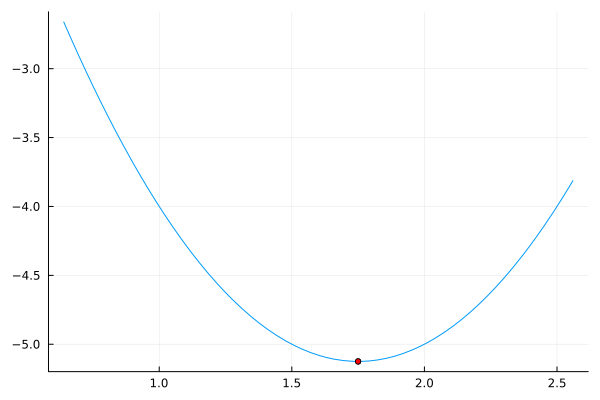

In [158]:
plot(f, a, b, leg=false)
scatter!([7/4], [f(7/4)], c=:blue, ms=3)
scatter!([xᵏ], [f(xᵏ)], c=:red, ms=3)

In [159]:
f(x) = if x ≤ 1
    (x - 1)^2
elseif x ≤ 5
    (x - 1)* 0.5
else
    sqrt(x - 1)
end

a, b = intervalo_inicial(f, 0)
k, xᵏ= Part_igual(f, a, b)
k, xᵏ, ForwardDiff.derivative(f, xᵏ)

(34, 0.9999998295054626, -3.4098907475410556e-7)

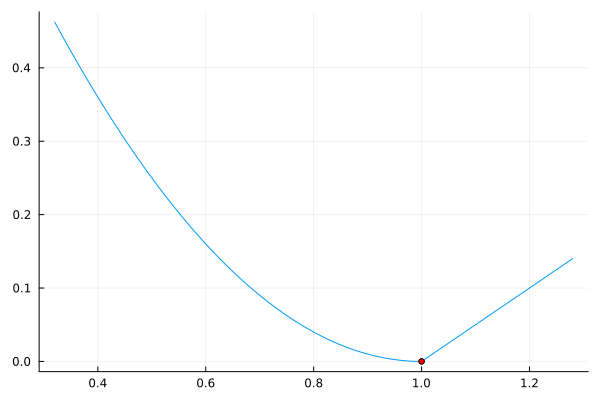

In [160]:
f(x) = if x ≤ 1
    (x - 1)^2
elseif x ≤ 5
    (x - 1)* 0.5
else
    sqrt(x - 1)
end

a, b = intervalo_inicial(f, 0)
k, xᵏ= Part_igual(f, a, b)
k, xᵏ, ForwardDiff.derivative(f, xᵏ)

plot(f, a, b, leg=false)
scatter!([1], [f(1)], c=:blue, ms=3)
scatter!([xᵏ], [f(xᵏ)], c=:red, ms=3)

# Método da Seção áurea

In [162]:
function busca_secao_aurea(f, a, b, n)
    rho = Base.MathConstants.golden-1
    v = rho * b + (1 - rho)*a
    yv = f(v)
    for i = 1 : n-1
        u = rho*a + (1 - rho)*b
        yu = f(u)
        if yu < yv
            b, v, yv = v, u, yu
        else
            a, b = b, u
        end
    end
    return a < b ? (a, b) : (b, a)
end

busca_secao_aurea (generic function with 1 method)

In [163]:
f(x)= 2*x^2 - 7*x+1
#f(0)
a, b = 1, 5
#a, b = intervalo_inicial(f, 0)
#k, xᵏ= Part_igual(f, a, b)
#k, xᵏ, ForwardDiff.derivative(f, xᵏ)

busca_secao_aurea(f, a, b, 40)


(1.749999980873493, 1.7500000091575707)

# Busca de ajuste quadrático

In [165]:
function busca_ajuste_quadratico(f, a, b, c, n)
    ya, yb, yc = f(a), f(b), f(c)
    for i in 1:n-3
        x = 0.5*(ya*(b^2-c^2)+yb*(c^2-a^2)+yc*(a^2-b^2)) /(ya*(b-c) +yb*(c-a) + yc*(a-b))
        yx = f(x)
        if x > b
            if yx > yb
                c, yc = x, yx
            else
                a, ya, b, yb = b, yb, x, yx
            end
        elseif x < b
            if yx > yb
                a, ya = x, yx
            else
                c, yc, b, yb = b, yb, x, yx
            end
        end
    end
return (a, b, c)
end

busca_ajuste_quadratico (generic function with 1 method)

In [166]:
f(x)= 2*x^2 - 7*x+1
#f(0)
a, b = 1.0, 5.0
#a, b = intervalo_inicial(f, 0)
#k, xᵏ= Part_igual(f, a, b)
#k, xᵏ, ForwardDiff.derivative(f, xᵏ)
# busca_secao_aurea(f, a, b, 40)

a, xᵏ, b = busca_ajuste_quadratico(f, a, b, (a+b)/2, 40)

f(xᵏ), ForwardDiff.derivative(f, xᵏ)

(-5.125, 0.0)

# Método da biseção

In [168]:
function bissecao(df, a, b, epsilon)
    if a > b; a,b = b,a; end
    ya, yb = df(a), df(b)
    if ya == 0; b = a; end
    if yb == 0; a = b; end
    
    while b - a > epsilon
        x = (a+b)/2
        y = df(x)
        if y == 0
            a, b = x, x
        elseif sign(y) == sign(ya)
            a = x
        else
            b = x
        end
    end
return (a,b)
end

bissecao (generic function with 1 method)

In [169]:
f(x)= 2*x^2 - 7*x+1
df(x) = ForwardDiff.derivative(f,x)
#f(0)
a, b = 1.0, 5.0
#a, b = intervalo_inicial(f, 0)
#k, xᵏ= Part_igual(f, a, b)
#k, xᵏ, ForwardDiff.derivative(f, xᵏ)
# busca_secao_aurea(f, a, b, 40)

#a, xᵏ, b = busca_ajuste_quadratico(f, a, b, (a+b)/2, 40)

bissecao(df, a, b, 1e-6)
#f(xᵏ), ForwardDiff.derivative(f, xᵏ)

(1.75, 1.75)

In [170]:
function intervalo_bissecao(df, a, b; k=2)
    if a > b; a,b = b,a; end
    centro, metade = (b+a)/2, (b-a)/2
    while df(a)*df(b) > 0
        metade *= k
        a = centro - metade
        b = centro + metade
    end
    return (a,b)
end

intervalo_bissecao (generic function with 1 method)

In [171]:
intervalo_bissecao(df, rand(), rand())

(-1.1977076574612162, 2.1131533261079882)

In [172]:
f(x)= 2*x^2 - 7*x+1
df(x) = ForwardDiff.derivative(f,x)
#f(0)
a, b = intervalo_bissecao(df, rand(), rand())
a, b = bissecao(df, a, b, 1e-6)

xᵏ = (a+b)/2

f(xᵏ), ForwardDiff.derivative(f, xᵏ)

(-5.124999999999891, -9.35988770045526e-7)